#  Entrenamiento y evaluación del modelo Regresión lineal para predicción
Este notebook forma parte del Anexo IV del Trabajo Fin de Máster.
En él se describe el proceso completo de carga de datos, preprocesado,
entrenamiento, validación y evaluación del modelo regresion lineal.

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression



## Librerías y configuración del entorno

In [4]:
df_ambiente= pd.read_csv('prueba2.csv', sep=',', header=None)
df_week_40=pd.read_csv('s40.csv', sep=',', header=None)

df_ambiente.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,#group,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false,false
1,#datatype,double,double,double,double,double,double,double,double,long,long,double,long,double,double,double,double,dateTime:RFC3339
2,#default,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,bvoc,co2eq,gas,gas_resistencia,hum,humedad,iaq,lux,pm10_0,pm1_0,pm25_pred_1h,pm2_5,pres,presion,temp,temperatura,time
4,NaN,NaN,NaN,27.7,NaN,81.4,NaN,NaN,1.67,4,2,NaN,3,1018.05,NaN,16.75,NaN,2025-10-06T00:01:49.804443847Z


In [5]:
#Miro numero de filas y columnas 
df_ambiente.shape

(8585, 18)

In [6]:
#Miro como son mis variables 
df_ambiente.dtypes

0     object
1     object
2     object
3     object
4     object
5     object
6     object
7     object
8     object
9     object
10    object
11    object
12    object
13    object
14    object
15    object
16    object
17    object
dtype: object

In [7]:
df_ambiente.isna().sum()

0     8582
1     8582
2     8582
3      881
4     8582
5      881
6     8582
7     8582
8      881
9      881
10     881
11    7702
12     881
13     881
14    8582
15     881
16    8582
17       1
dtype: int64

In [8]:

df_ambiente = df_ambiente.drop(df_ambiente.columns[[0,1,2,4,6,7,11,14,16]], axis=1)

df_ambiente = df_ambiente.drop(df_ambiente.index[[0,1,2]], axis=0)


df_ambiente

,3,5,8,9,10,12,13,15,17
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [9]:

nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_ambiente.columns = nombres_columnas

df_ambiente = df_ambiente.drop(df_ambiente.index[[0]], axis=0)
df_ambiente

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
4,27.7,81.4,1.67,4,2,3,1018.05,16.75,2025-10-06T00:01:49.804443847Z
5,26.85,81.16,0.83,5,3,4,1018.16,16.61,2025-10-06T00:07:22.185193661Z
6,27.34,79.99,1.67,5,3,4,1018.21,16.49,2025-10-06T00:12:55.194415384Z
7,31.19,74.74,1.67,5,3,4,1018.27,16.43,2025-10-06T00:18:28.510440004Z
8,41.54,69.17,1.67,4,2,3,1018.32,16.43,2025-10-06T00:24:01.520771861Z
...,...,...,...,...,...,...,...,...,...
8580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:25:00Z
8581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:30:00Z
8582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:35:00Z
8583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-03T19:40:00Z


In [10]:
df_week_40 = df_week_40.drop(df_week_40.columns[[0,1,2,4,6,7,13,15]], axis=1)
df_week_40 = df_week_40.drop(df_week_40.index[[0,1,2]], axis=0)

In [11]:
 
nombres_columnas = ['gas','humedad','lux','pm10','pm1','pm2.5','presion','temp','Fecha/hora']
df_week_40.columns = nombres_columnas

df_week_40 = df_week_40.drop(df_ambiente.index[[0]], axis=0)
df_week_40

,gas,humedad,lux,pm10,pm1,pm2.5,presion,temp,Fecha/hora
3,gas,hum,lux,pm10_0,pm1_0,pm2_5,pres,temp,time
5,19.84,75.3,0.83,17,12,16,1014.07,19.62,2025-09-30T00:07:10.215775097Z
6,19.79,74.47,0.83,17,11,15,1014.05,19.62,2025-09-30T00:12:47.292697787Z
7,19.94,74.01,0.83,16,12,15,1014.03,19.61,2025-09-30T00:18:19.300693929Z
8,20.35,73.77,0.83,16,12,15,1014,19.6,2025-09-30T00:23:51.395464121Z
...,...,...,...,...,...,...,...,...,...
1803,30.8,72.47,0.83,14,10,13,1016.12,21.29,2025-10-02T23:33:50.851340875Z
1804,30.03,72.77,0.83,12,9,12,1016.16,21.19,2025-10-02T23:39:23.771511753Z
1805,28.51,74.13,0.83,14,9,12,1016.2,21.02,2025-10-02T23:44:56.40615835Z
1806,26.53,73.81,0.83,14,10,13,1016.26,20.85,2025-10-02T23:50:28.642935837Z


In [12]:
print(df_week_40.columns)
print(df_ambiente.columns)


df_week_40.columns = df_ambiente.columns  


df_completo = pd.concat([df_week_40, df_ambiente], axis=0, ignore_index=True)

Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')
Index(['gas', 'humedad', 'lux', 'pm10', 'pm1', 'pm2.5', 'presion', 'temp',
       'Fecha/hora'],
      dtype='object')


In [13]:
df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.tz_localize(None)         
df_completo['Fecha/hora'] = df_completo['Fecha/hora'].dt.floor('s')   
df_completo = df_completo.sort_values(by='Fecha/hora', ascending=True)

# Mostrar el DataFrame combinado
print(df_completo.head())

       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
771  17.92   76.81  0.83   30  18    27  1012.43   20.8 2025-09-28 22:00:44
772  17.86   77.07  0.83   33  18    28  1012.44  20.75 2025-09-28 22:06:16
773  17.85   77.17  0.83   31  18    27  1012.47  20.69 2025-09-28 22:11:49
774  17.71   77.09  0.83   31  19    27   1012.5  20.66 2025-09-28 22:17:22
775  17.74   76.98  0.83   32  18    27  1012.53  20.65 2025-09-28 22:22:54


C:\Users\aleoj\AppData\Local\Temp\ipykernel_12576\2805907038.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'], errors='coerce')


In [14]:
df_completo['Fecha/hora'] = pd.to_datetime(df_completo['Fecha/hora'])


inicio_datos = pd.to_datetime('2025-09-29 00:00:00') 
final_datos = pd.to_datetime('2025-10-26 23:59:59')  

df_completo = df_completo[
    (df_completo['Fecha/hora'] >= inicio_datos) &
    (df_completo['Fecha/hora'] <= final_datos)
]


df_completo = df_completo.sort_values(by='Fecha/hora')


print(df_completo.head())


       gas humedad   lux pm10 pm1 pm2.5  presion   temp          Fecha/hora
514   16.1   80.73  0.83   20  14    19  1012.23  19.81 2025-09-29 00:02:53
515  16.22   80.81  0.83   22  14    20  1012.23  19.77 2025-09-29 00:08:26
516  16.02   80.96  0.83   22  14    20  1012.25  19.73 2025-09-29 00:13:58
517   15.8   80.77  0.83   25  16    22  1012.28   19.7 2025-09-29 00:19:31
518   15.8   80.58  0.83   22  15    20   1012.3  19.69 2025-09-29 00:25:11


In [15]:
df_completo.dtypes

gas                   object
humedad               object
lux                   object
pm10                  object
pm1                   object
pm2.5                 object
presion               object
temp                  object
Fecha/hora    datetime64[ns]
dtype: object

In [16]:
df_completo.isna().sum()

gas           0
humedad       0
lux           0
pm10          0
pm1           0
pm2.5         0
presion       0
temp          0
Fecha/hora    0
dtype: int64

In [17]:

rows_with_nan = df_completo[df_completo.isna().any(axis=1)]

print(rows_with_nan[['Fecha/hora']])


Empty DataFrame
Columns: [Fecha/hora]
Index: []


In [18]:

nan_by_date = df_completo.groupby(df_completo['Fecha/hora'].dt.date).apply(lambda x: x.isna().sum())
print(nan_by_date)

            gas  humedad  lux  pm10  pm1  pm2.5  presion  temp  Fecha/hora
Fecha/hora                                                                
2025-09-29    0        0    0     0    0      0        0     0           0
2025-09-30    0        0    0     0    0      0        0     0           0
2025-10-01    0        0    0     0    0      0        0     0           0
2025-10-02    0        0    0     0    0      0        0     0           0
2025-10-03    0        0    0     0    0      0        0     0           0
2025-10-04    0        0    0     0    0      0        0     0           0
2025-10-05    0        0    0     0    0      0        0     0           0
2025-10-06    0        0    0     0    0      0        0     0           0
2025-10-07    0        0    0     0    0      0        0     0           0
2025-10-08    0        0    0     0    0      0        0     0           0
2025-10-09    0        0    0     0    0      0        0     0           0
2025-10-10    0        0 

In [19]:
fecha_hora=df_completo['Fecha/hora']

df_completo = df_completo.apply(pd.to_numeric, errors='ignore')

df_completo['Fecha/hora'] = fecha_hora

df_completo.dtypes

gas                  float64
humedad              float64
lux                  float64
pm10                   int64
pm1                    int64
pm2.5                  int64
presion              float64
temp                 float64
Fecha/hora    datetime64[ns]
dtype: object

In [19]:
print(df_completo)

         gas  humedad   lux  pm10  pm1  pm2.5  presion   temp  \
514    16.10    80.73  0.83    20   14     19  1012.23  19.81   
515    16.22    80.81  0.83    22   14     20  1012.23  19.77   
516    16.02    80.96  0.83    22   14     20  1012.25  19.73   
517    15.80    80.77  0.83    25   16     22  1012.28  19.70   
518    15.80    80.58  0.83    22   15     20  1012.30  19.69   
...      ...      ...   ...   ...  ...    ...      ...    ...   
7275  118.88    71.84  0.83     3    2      3  1014.20  11.95   
7276  143.41    69.92  0.83     3    2      2  1014.21  11.96   
7277  163.57    69.40  0.83     2    1      2  1014.24  11.93   
7278  180.30    69.59  0.83     3    1      2  1014.27  11.88   
7279  190.86    68.88  0.83     2    1      1  1014.28  11.84   

              Fecha/hora  
514  2025-09-29 00:02:53  
515  2025-09-29 00:08:26  
516  2025-09-29 00:13:58  
517  2025-09-29 00:19:31  
518  2025-09-29 00:25:11  
...                  ...  
7275 2025-10-26 23:35:48  
727

# Predecir el PM2.5

In [20]:

df_ambientev1= df_completo
# 0) ordenar por tiempo y resetear índice 
df_ambientev1 = df_ambientev1.sort_values('Fecha/hora').reset_index(drop=True)


# creo en mi dataset una nueva columna que sera el pm2.5_t+1) mi futuro target 
df_ambientev1['pm2.5_t+1'] = df_ambientev1['pm2.5'].shift(-12)


#creo en mi dataset una nueva columna que sera el pm2.5_lag1

df_ambientev1['pm2.5_lag1'] = df_ambientev1['pm2.5'].shift(1)

df_ambientev1['pm2.5_lag3'] = df_ambientev1['pm2.5'].shift(3)

df_ambientev1['pm2.5_lag6'] = df_ambientev1['pm2.5'].shift(6)

df_ambientev1['pm2.5_lag12'] = df_ambientev1['pm2.5'].shift(12)

df_ambientev1['pm2.5_mean_12'] = df_ambientev1['pm2.5'].rolling(12).mean().shift(1).round(1)


df_ambientev1['gas_lag1'] = df_ambientev1['gas'].shift(1)

df_ambientev1['gas_lag3'] = df_ambientev1['gas'].shift(3)

df_ambientev1['humedad_lag1'] = df_ambientev1['humedad'].shift(1)

df_ambientev1['humedad_lag3'] = df_ambientev1['humedad'].shift(3)


columnas = [
    "gas","humedad","temp","lux",
    "pm2.5_lag1","pm2.5_lag3","pm2.5_lag6","pm2.5_lag12","pm2.5_mean_12",
    "gas_lag1","gas_lag3","humedad_lag1","humedad_lag3"
]


target_full = df_ambientev1[['Fecha/hora','pm2.5_t+1']].copy()


df_model = df_ambientev1.dropna(subset=columnas + ["pm2.5_t+1"]).copy()


X = df_model[columnas]
y = df_model['pm2.5_t+1']

In [21]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)



In [22]:

from sklearn.preprocessing import MinMaxScaler


feature_cols = ["gas","humedad","temp","lux",
                "pm2.5_lag1","pm2.5_lag3","pm2.5_lag6","pm2.5_lag12","pm2.5_mean_12",
                "gas_lag1","gas_lag3","humedad_lag1","humedad_lag3"]

scaler_1 = MinMaxScaler()


X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_scaled_train = pd.DataFrame(
    scaler_1.fit_transform(X_train_df),
    columns=feature_cols,
    index=X_train_df.index
)

X_val_df = pd.DataFrame(X_val, columns=feature_cols)
X_scaled_val = pd.DataFrame(
    scaler_1.transform(X_val_df),
    columns=feature_cols,
    index=X_val_df.index
)


X_test_df = pd.DataFrame(X_test, columns=feature_cols)
X_scaled_test = pd.DataFrame(
    scaler_1.transform(X_test_df),
    columns=feature_cols,
    index=X_test_df.index
)



In [24]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_scaled_train, y_train)


LinearRegression()

In [25]:
#Aqui le digo con otros valores que no has visto dime que predices
y_val_pred = modelo.predict(X_scaled_val)

#utilizo metricas MSE: error medio cuadratico cuanto mas pequeño mejor // y R^2 mide cuánto del comportamiento de y logra explicar el modelo.
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")



MSE: 11.7215
R²: -0.3523


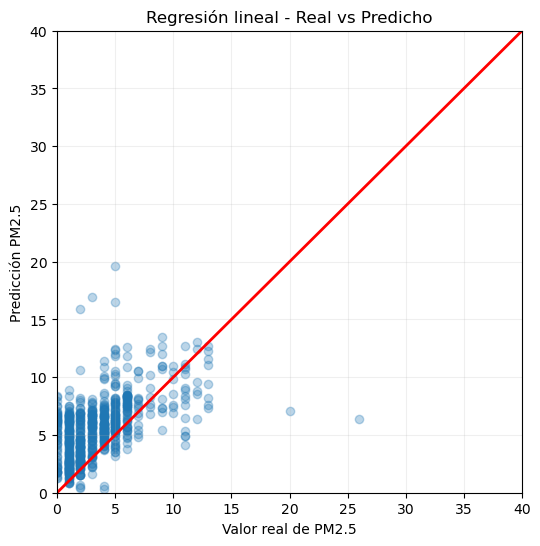

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Real vs Predicho
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_val_pred, alpha=0.3)
plt.plot([0, max(y_test)], [0, max(y_test)], color='red', linewidth=2)
plt.xlim(0, max(y_test))
plt.ylim(0, max(y_test))
plt.grid(alpha=0.2)



plt.xlabel("Valor real de PM2.5")
plt.ylabel("Predicción PM2.5")
plt.title("Regresión lineal - Real vs Predicho")

plt.show()



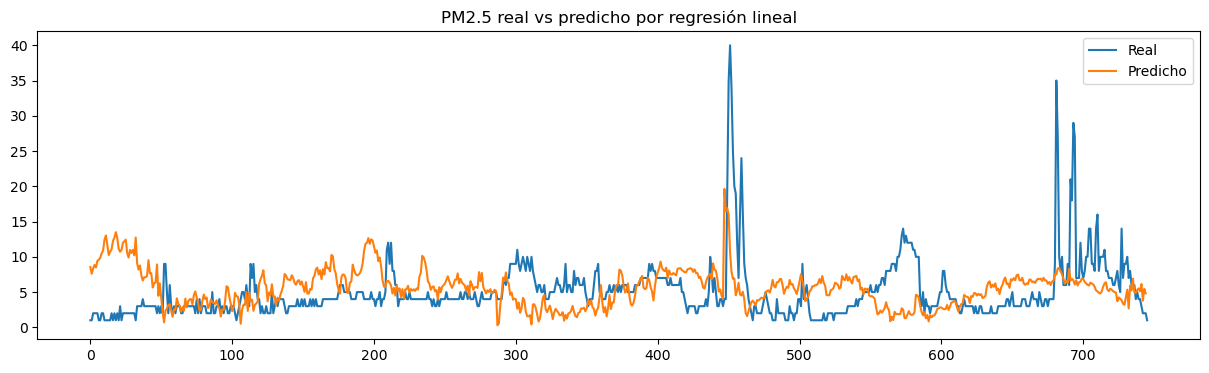

In [27]:
plt.figure(figsize=(15,4))
plt.plot(y_test.values, label="Real")
plt.plot(y_val_pred, label="Predicho")
plt.legend()
plt.title("PM2.5 real vs predicho por regresión lineal")
plt.show()
